# Projeto MENU-LATERAL
Feito por João Andre [@jandrexm](https://github.com/jandrexm) | Última modificação: 05/06/2026


<br>
<hr style="border: 1px solid #dddddd00;">
<br>
   

Uma empresa lançou um teste A/B para avaliar a usabilidade do menu lateral de sua plataforma. O teste compara duas configurações:
1. Acesso direto a uma página específica do site (Nível 0 do menu lateral).
2. Acesso à mesma página, mas sob uma aba mais geral (Nível 1 do menu lateral).

O objetivo do desafio a seguir foi determinar qual configuração do menu lateral leva a mais acessos e conversões para a página
específica da plataforma.

Com a justificativa de que identificar a configuração mais eficaz ajudará a otimizar a navegação do site para aumentar o engajamento
dos usuários.

<br>
<hr style="border: 1px solid #dddddd00;">
<br>

## SUMÁRIO
[1. Configurações e bibliotecas](#1-configurações-e-bibliotecas)

[2. Carregamento e tratamento dos dados](#2-carregamento-e-tratamento-dos-dados)

[3. Questões levantadas](#3-questões-levantadas)

<br>
<hr style="border: 1px solid #dddddd00;">
<br>



## 1. Configurações e bibliotecas

Abaixo realiza-se a configuração inicial do ambiente e a importação das bibliotecas utilizadas nesta análise:
* **Pandas:** Para manipulação e agregação dos dados.
* **IpyDataGrid:** Para visualização interativa das tabelas de dados.
* **SciPy:** Para a aplicação do teste de significância estatística.


*Nota: O comando de instalação (`%pip`) está comentado por padrão para agilizar as execuções subsequentes. Descomente a linha caso seja a primeira vez executando este notebook.*

In [ ]:
# A linha linha de comando a seguir instala as bibliotecas listadas em requirements.txt.
#%pip install -r requirements.txt -q
# Obs.: Remover o comentário da linha acima no primeiro uso ou para atualizar as bibliotecas.

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy import stats
from itables import show
from ipydatagrid import DataGrid, TextRenderer, Expr
from scipy.stats import shapiro

DIRETORIO_PLOTS = 'plots'
if not os.path.exists(DIRETORIO_PLOTS):
    os.makedirs(DIRETORIO_PLOTS)
    print(f"Diretório '{DIRETORIO_PLOTS}' criado com sucesso.")


paleta = ["#994D70", "#652643"] 
sns.set_theme(style="whitegrid", palette=paleta)


Diretório 'plots' criado com sucesso.




## 2. Carregamento e tratamento dos dados

A seguir os dados do teste A/B dispostos na planilha _ab_test_data.xlsx_ serão importados como o dataset `dados`.


In [4]:
# Importando os dados do arquivo Excel e exibindo-os em formato de tabela interativa
dados = pd.read_excel("ab_test_data.xlsx")
show(dados, paging=True, lengthMenu=[15, 30, 50], allow_html=True)


# Contagem de valores únicos da coluna `user_id`
total_usuarios_unicos = dados['user_id'].nunique()
print(f"\nTotal de usuários únicos: {total_usuarios_unicos} ---------------")


# Exibindo as informações estruturais e estatística descritiva
print(f"\nInformações estruturais ----------------------\n")
dados.info()
print(f"-"*45)

Loading ITables v2.8.0 from the internet... (need help?)



Total de usuários únicos: 1295 ---------------

Informações estruturais ----------------------

<class 'pandas.DataFrame'>
RangeIndex: 2305 entries, 0 to 2304
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           2305 non-null   int64         
 1   device            2305 non-null   str           
 2   country           2305 non-null   str           
 3   timestamp         2305 non-null   datetime64[us]
 4   group             2305 non-null   str           
 5   converted         2305 non-null   int64         
 6   session_duration  2269 non-null   float64       
 7   hour_of_day       2305 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(3)
memory usage: 144.2 KB
---------------------------------------------



A partir da inspeção acima, foram identificados os seguintes pontos que necessitam atenção:

- **Tipagem:** A coluna de `user_id` será convertida para _string_, já `converted` será convertida em booleana (True/False);

- **Redundância:** A coluna `hour_of_day` é redundante com `timestamp` e será removida;

- **Usuários duplicados:** Múltiplos registros para do mesmo `user_id` em diferentes países, indicando usuários retornantes ou possíveis falhas na coleta;

- **Valores nulos:** Sessões com duração nula (`NaN`).




A seguinte etapa busca observar o histórico de acessos irregulares agrupando por `user_id`, ordenando a base pelo `timestamp` e destacando valores nulos em `session_duration`.

In [5]:
# i. Convertendo tipos de dados e removendo colunas
dados["converted"] = dados["converted"].astype(bool)
dados["user_id"] = dados["user_id"].astype(str)
dados = dados.drop(columns=["hour_of_day"])


# ii. Identificando ids de usuários duplicados
ids_duplicados = dados[dados.duplicated('user_id', keep=False)]['user_id'].unique()


# iii. Identificando usuários com mais de um país
ids_multipais = dados.groupby('user_id')['country'].nunique()
ids_multipais = ids_multipais[ids_multipais > 1].index.tolist()


# iv. Identificando usuários com ao menos um NaN em 'session_duration'
ids_com_nan = dados[dados['session_duration'].isna()]['user_id'].unique()


# v. Interseção: Usuários que são DUPLICADOS E MULTIPAÍS E COM NAN
ids_alvo = list(set(ids_duplicados) & set(ids_multipais) & set(ids_com_nan))


# vi. Filtrando a base original e ordenar
dados_alvo = dados[dados['user_id'].isin(ids_alvo)].copy()
dados_alvo['id_temp'] = dados_alvo['user_id'].astype(int)
dados_sorted_alvo = dados_alvo.sort_values(by=['id_temp', 'timestamp']).drop(columns=['id_temp'])


# vii. Exibindo tabela com observações contendo user_id duplicados, multipaís e NaNs
def destacar_linhas_nan(df):
    return df.style.apply(
        lambda row: ['color: red'] * len(row) 
        if pd.isna(row['session_duration']) else [''] * len(row), 
        axis=1
    )
show(destacar_linhas_nan(dados_sorted_alvo), paging=True, lengthMenu=[15, 30, 50], allow_html=True)


# viii. Contagem de usuários únicos na base filtrada
total_usuarios_alvo = dados_sorted_alvo['user_id'].nunique()
print(f"\nTotal de usuários únicos na base filtrada: {total_usuarios_alvo}")
lista_usuarios_alvo = dados_sorted_alvo['user_id'].unique().tolist()
print(lista_usuarios_alvo)
print(f"-"*45)

Loading ITables v2.8.0 from the internet... (need help?)



Total de usuários únicos na base filtrada: 16
['37', '47', '575', '700', '861', '946', '957', '967', '1123', '1137', '1151', '1161', '1301', '1397', '1824', '1979']
---------------------------------------------




A partir da identificação de irregularidades no dataset (duplicidade + multiplicidade de países + falhas de coleta) foi possível concluir que houve falhas sistêmicas para 16 usuários específicos. 

Para garantir a integridade dos dados do teste A/B são sugeridas as seguintes alterações:

- **Padronização geográfica (_first-touch_):** Corrigir registros com conflito de localização na coluna `country` priorizando o primeiro acesso;

- **Limpeza de integridade:** Exclusão dos registros que contiverem valores nulos (NaN) na coluna `session_duration`.



Abaixo, realiza-se a aplicação destas alterações e a exportação do dataset consolidado para criação da dashboard no DataStudio (Looker) .

In [9]:
# i. Padronização geográfica (first-touch)
mapa_pais_correto = (
    dados.dropna(subset=['country'])
    .sort_values('timestamp')
    .groupby('user_id')['country']
    .first()
)
dados_tratados = dados.copy()
dados_tratados['country'] = dados_tratados['user_id'].map(mapa_pais_correto)


# ii. Limpeza de integridade (Remoção de NaNs em session_duration)
dados_tratados= dados_tratados.dropna(subset=['session_duration']).copy()


# iii. Exportação para CSV (pronto para o Looker Studio)
dados_tratados.to_csv("ab_test_treated_data.csv", index=False)


print(f"Base Final: {len(dados_tratados)} registros;")
print("Dataset exportado com sucesso para 'ab_test_treated_data.csv';")
print(f"Tratamento inicial concluído!")

Base Final: 2269 registros;
Dataset exportado com sucesso para 'ab_test_treated_data.csv';
Tratamento inicial concluído!


## 3. Validação e testes estatísticos

Nesta seção, realiza-se a validação diagnóstica da base de dados (`dados_tratados`) antes da aplicação dos testes de inferência. O objetivo é assegurar a integridade das métricas analisadas, auditando possíveis anomalias na coleta (estatística descritiva), validando a distribuição (teste de normalidade) e determinando a significância estatística dos resultados (teste de Mann-Whitney) observados entre os grupos. Esta etapa é fundamental para evitar conclusões enviesadas por falhas técnicas, garantindo que as decisões de produto sejam baseadas em evidências estatisticamente robustas.

## 3.1 Estatística descritiva

Abaixo realiza-se a inspeção das variáveis categóricas (`device`, `country`) com contagem de valores únicos, predominantes e sua frequência, e temporais (`timestamp`) com máximos, mínimos e quartis. Destaca-se sobre estas que:

a. O dispositivo Desktop foi o que apresentou maior número de acessos com 778 entradas;

b. Foram registrados acessos de 8 países, sendo Reino Unido o mais frequente com 235 entradas;

c. Todos os registros aconteceram entre 0h e 23h:58 do dia 01 de junho de 2024.



A respeito da variável numérica de interesse, `session_duration`, a conferência de máximos, mínimos, quartis, média e desvio padrão permitiu observar a predominância de sessões com duração de 0 segundos. Para validar o impacto desta concentração na distribuição, realiza-se abaixo um estudo comparativo via boxplots.

In [14]:
display(dados_tratados[['device', 'country','timestamp','session_duration']].describe(include='all'))


,device,country,timestamp,session_duration
count,2269,2269,2269,2269.000000
unique,3,8,NaN,NaN
top,Desktop,Reino Unido,NaN,NaN
freq,778,325,NaN,NaN
mean,NaN,NaN,2024-06-01 12:03:07.351256,5.976675
min,NaN,NaN,2024-06-01 00:00:00,0.000000
25%,NaN,NaN,2024-06-01 07:00:00,0.000000
50%,NaN,NaN,2024-06-01 11:53:00,0.000000
75%,NaN,NaN,2024-06-01 17:18:00,4.110315
max,NaN,NaN,2024-06-01 23:58:00,64.446394


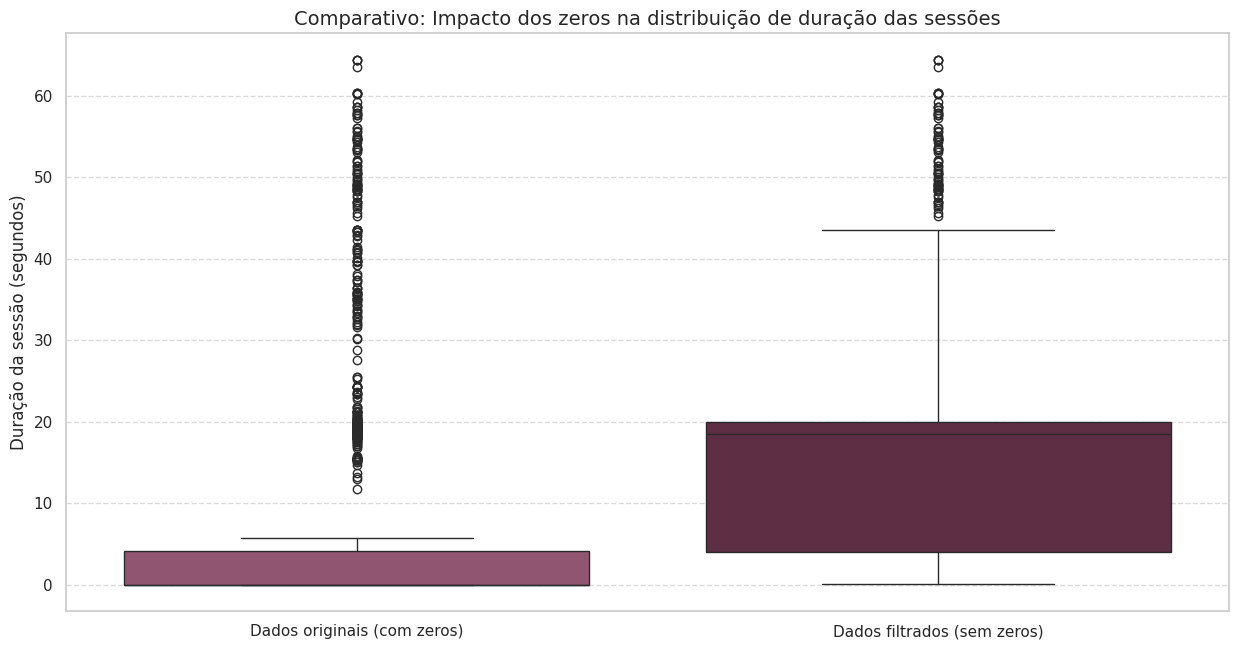

In [ ]:
# i. Preparando dados para plot comparativo
dados_com_zeros = dados_tratados.copy()
dados_com_zeros['categoria'] = 'Dados originais (com zeros)'

dados_sem_zeros = dados_tratados[dados_tratados['session_duration'] > 0].copy()
dados_sem_zeros['categoria'] = 'Dados filtrados (sem zeros)'

df_comparativo = pd.concat([dados_com_zeros, dados_sem_zeros])

# ii. Boxplot comparativo de duração das sessões (com e sem zeros)

plt.figure(figsize=(15, 7.5))
sns.boxplot( data=df_comparativo, x='categoria', y='session_duration', hue='categoria', palette=paleta, legend=False)

plt.title('Comparativo: Impacto dos zeros na distribuição de duração das sessões', fontsize=14)
plt.ylabel('Duração da sessão (segundos)', fontsize=12)
plt.xlabel('') 

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(DIRETORIO_PLOTS, 'comparativo_distribuicao.png'), dpi=300, bbox_inches='tight')

plt.show()

O gráfico comparativo do impacto dos zeros na distribuição de duração de sessões (acima) confirma visualmente como o excesso de valores nulos comprime a representatividade da amostra.
No cenário de produto, este comportamento é ambíguo: embora a interpretação técnica sugira uma taxa elevada de rejeição, a predominância de zeros ser resultado de <u>falhas sistêmicas</u> (como o levantado sobre as colunas `user_id` e `country`) ou representar sessões que o usuário permaneceu por <u>tempo insuficiente</u> na página para ativar a cronometragem. 

<blockquote> <b>
<br>
Esta incerteza sobre a origem dos zeros reforça a prudência de isolar este grupo nas análises de performance, evitando que o ruído técnico ou o comportamento atípico de navegação enviesem a avaliação da nova funcionalidade.
<br> <br>
</b> </blockquote>


### 3.2 Teste de normalidade (Shapiro-Wilk)

Nesta etapa, verifica-se a distribuição da variável ``session_duration`` nos grupos "A" e "B" utilizando o teste de Shapiro-Wilk e análise de histogramas. O objetivo é determinar se a distribuição dos dados segue uma curva normal (Gaussiana), o que orientará a escolha dos testes de hipótese subsequentes.

Obs.: Será utilizado o dataset _dados_engajados_, corresponde aos _dados_tratados_ sem os zeros.


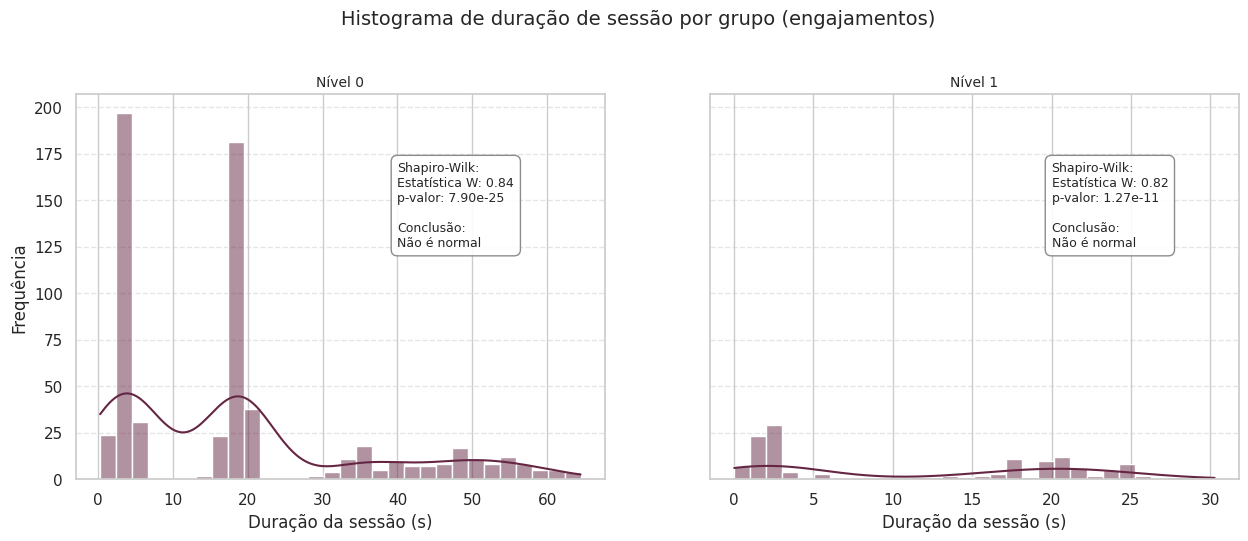

In [ ]:
# i.
dados_engajados = dados_tratados[dados_tratados['session_duration'] > 0].copy()

# ii.

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

grupos = sorted(dados_engajados['group'].unique())

posicoes = {'Nível 0': (40, 125), 'Nível 1': (20, 125)}

for i, grupo in enumerate(grupos):
    dados_nivel = dados_engajados[dados_engajados['group'] == grupo]['session_duration']
    
    # Executa o teste de Shapiro-Wilk
    stat, p_valor = shapiro(dados_nivel)
    
    # Histograma
    sns.histplot(data=dados_nivel, ax=axes[i], color='#652643', kde=True, bins=30)
    
    # Preparação do texto
    status = "Parece normal" if p_valor > 0.05 else "Não é normal"
    texto_resultado = f"Shapiro-Wilk:\nEstatística W: {stat:.2f}\np-valor: {p_valor:.2e}\n\nConclusão:\n{status}"

    # Posicionamento dinâmico
    x_pos, y_pos = posicoes[grupo]
    axes[i].text(x_pos, y_pos, texto_resultado, fontsize=9, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))
    axes[i].set_title(f'{grupo}', fontsize=10)
    axes[i].set_xlabel('Duração da sessão (s)')
    axes[i].set_ylabel('Frequência' if i == 0 else '')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)  

plt.suptitle('Histograma de duração de sessão por grupo (engajamentos)', fontsize=14, y=1.05)

# Salvar o gráfico
plt.savefig(os.path.join(DIRETORIO_PLOTS, 'histograma_normalidade.png'), dpi=300, bbox_inches='tight')
plt.show()

## 3. Questões levantadas

1. Qual configuração do menu lateral levou mais usuários a acessarem a página específica?
2. Qual o tempo médio de sessão para cada configuração do menu?
3. Qual é a taxa de conversão para cada configuração do menu?
4. A diferença nos acessos entre as configurações é estatisticamente significativa?
5. Quais insights podem ser derivados dos dados para otimizar a navegação do site e aumentar o engajamento dos usuários?
6. Existe alguma tendência temporal (comportamento ao longo dia) nos acessos ou conversões para cada configuração do menu?
7. Quais recomendações você faria com base nos dados analisados para otimizar a navegação do site?

In [44]:
# 1. Qual configuração do menu levou mais usuários a acessar a página específica?
acessos_por_menu = dados_tratados.groupby('group')['user_id'].nunique().sort_values(ascending=False)

# 2. Qual o tempo médio de sessão para cada configuração?
tempo_medio = dados_tratados.groupby('group')['session_duration'].mean()

# 3. Qual é a taxa de conversão para cada configuração?
# (Soma dos convertidos / total de sessões)
taxa_conversao = dados_tratados.groupby('group')['converted'].mean()

# Você pode consolidar tudo num único DataFrame para facilitar a visualização
resumo_teste = pd.DataFrame({
    'Total Usuários': acessos_por_menu,
    'Tempo Médio (s)': tempo_medio,
    'Taxa de Conversão': taxa_conversao
})

display(resumo_teste)

,Total Usuários,Tempo Médio (s),Taxa de Conversão
group,,,
Nível 0,984,8.274386,0.439394
Nível 1,634,1.893106,0.165239
